## Tarea Red Neuronal
### Materia: Laboratorio de Aprendizaje Estádistico 
### Profesor: Antonio Manguart Paez
### Alumna: Maria Fernanda Gómez Flores

## Preparación de datos

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df = pd.read_csv('../Data/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.isna().mean()

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.010029
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [4]:
df = df.fillna(df.mean(numeric_only=True))

In [5]:
df.isna().mean()

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

## Target

In [6]:
df['target'] = df['median_house_value'] > 250000

In [7]:
df.target.mean()

np.float64(0.2801356589147287)

El target es 1 cuando la casa vale mas de 250000 y 0 cuando vale 250000 o menos

In [8]:
y = df['target']

X = df.copy()
del X['median_house_value']
del X['target']

ocean_proximity es categorica entonces la convierto a dummies

In [9]:
categoricas = [
    'ocean_proximity'
]

In [10]:
X = pd.get_dummies(X, columns=categoricas)

In [11]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,False,True,False


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

## Red neuronal

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model

Se escalan las variables antes de entrar a la red neuronal

GridSearchCV prueba diferentes combinaciones de capas ocultas, alpha y funciones de activación y selecciona la que obtiene el mejor AUC

In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=500000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ))
])

# --- Definir grid de hiperparámetros ---
param_grid = {
    'mlp__hidden_layer_sizes': [(10,), (20,), (20,10)],
    'mlp__alpha': [0.001, 0.1],
    'mlp__activation': ['relu', 'tanh'],
}

# --- GridSearchCV con validación cruzada interna (cv=5) ---
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)
grid.fit(X_train, y_train)

# --- Evaluar el modelo seleccionado en el conjunto de test ---
y_proba_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_proba_test)
print("AUC en el conjunto de test:", auc_test)

AUC en el conjunto de test: 0.938774202225851


In [15]:
grid.best_params_

{'mlp__activation': 'relu',
 'mlp__alpha': 0.001,
 'mlp__hidden_layer_sizes': (20,)}

El AUC de la red neuronal es 0.9388 por lo que el modelo logra separar bastante bien las dos clases

In [16]:
from sklearn.metrics import roc_curve

fpr_red, tpr_red, umbrales = roc_curve(
    y_true=y_test,
    y_score=y_proba_test
)

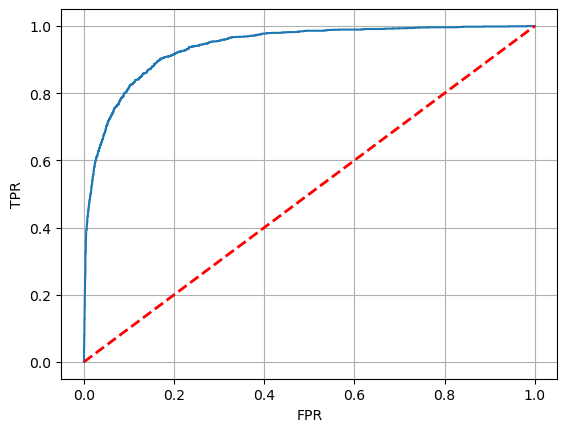

In [17]:
plt.plot(fpr_red,tpr_red)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()

## Calibración

In [18]:
df_calibracion = pd.DataFrame({
    'y': y_test,
    'probabilidad': y_proba_test
})

In [19]:
df_calibracion['probabilidad_bin'] = pd.qcut(
    df_calibracion['probabilidad'],
    q=10,
    labels=False
) + 1

In [20]:
calibracion = df_calibracion.groupby('probabilidad_bin').mean()
calibracion

,y,probabilidad
probabilidad_bin,,
1,0.006452,0.002256
2,0.011309,0.007422
3,0.012924,0.017495
4,0.022617,0.039324
5,0.053312,0.079080
6,0.134087,0.155292
7,0.282714,0.288413
8,0.525040,0.511572
9,0.796446,0.777827


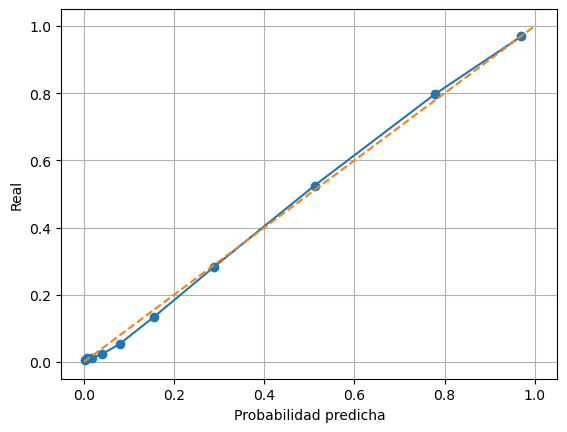

In [21]:
plt.plot(calibracion.probabilidad, calibracion.y, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Real")
plt.grid()

La calibración compara la probabilidad que predice la red neuronal con lo que realmente paso

Los puntos quedan bastante cerca de la diagonal por lo que en general las probabilidades estan bien calibradas

## Conclusión

La red neuronal obtuvo un AUC de 0.9388 por lo que logra separar bastante bien las casas mayores a 250000 de las que valen 250000 o menos

También se reviso la calibración y las probabilidades quedaron bastante cerca de los valores reales